## **Cálculo del radio de Giro** 

In [1]:
from funciones import calcular_radio_giro_promedio
import os
import gsd.hoomd
import numpy as np

In [7]:
def mapear_orden_cadenas_por_enlaces(frame, num_cadenas, longitud_cadena):
    """
    Utiliza la matriz de bonds para reconstruir la lista de índices de partículas
    en el orden molecular exacto (de cabeza a cola para cada cadena).
    """
    enlaces = frame.bonds.group
    
    # Creamos un diccionario de adyacencia (lista de vecinos)
    adj = {}
    for u, v in enlaces:
        if u not in adj: adj[u] = []
        if v not in adj: adj[v] = []
        adj[u].append(v)
        adj[v].append(v) # Para búsquedas bidireccionales si fuera necesario

    mapa_indices_ordenados = []
    
    # Tus datos muestran que las cabezas de las cadenas inician del índice 0 al (num_cadenas - 1)
    for cabeza in range(num_cadenas):
        cadena_actual = [cabeza]
        nodo_actual = cabeza
        
        # Caminamos a lo largo de los enlaces para encontrar los g-1 miembros restantes
        for _ in range(longitud_cadena - 1):
            vecinos = adj.get(nodo_actual, [])
            # Buscamos el vecino que NO hayamos agregado ya a la cadena
            siguiente_nodo = [v for v in vecinos if v not in cadena_actual]
            if siguiente_nodo:
                nodo_actual = siguiente_nodo[0]
                cadena_actual.append(nodo_actual)
            else:
                break # Por seguridad si se corta la cadena
                
        mapa_indices_ordenados.extend(cadena_actual)
        
    return np.array(mapa_indices_ordenados)

In [20]:
# ###############     Ejecución del Script      #######################

grado_polimerizacion = [8, 16, 24]
frame_inicial = 1
ruta_archivo_base = '/run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Polymers/P12_Polimero_Solvente'

for g in grado_polimerizacion:
    archivo = f'Poly-Solv_T0.60_epsSP1.00_monom_{g}.gsd'
    ruta_final = os.path.join(ruta_archivo_base, archivo)
    
    print(f'Analizando: {archivo}')
    
    try:
        with gsd.hoomd.open(name=ruta_final, mode='r') as trayectoria:
            num_frames = len(trayectoria)
            frames_analisis = num_frames - frame_inicial
            primer_frame = trayectoria[0]
            
            tipos_particulas = primer_frame.particles.types
            num_particulas = primer_frame.particles.N
            id_polimero = tipos_particulas.index('P')

            filtro_polimero = (primer_frame.particles.typeid == id_polimero)
            num_monomeros = np.sum(filtro_polimero)
            num_cadenas = num_monomeros // g

            print(f'  -> Total frames: {num_frames}')
            print(f'  -> Frame inicial {frame_inicial}')
            print(f'  -> Frames a analizar: {frames_analisis}')
            print(f'  -> Total de partículas: {num_particulas}')
            print(f"  -> Monómeros de polímero: {num_monomeros}")
            print(f"  -> Cadenas independientes: {num_cadenas}")

            # --- NUEVA ETAPA: Construir el mapa de ordenamiento molecular ---
            print("  -> Reconstruyendo topología molecular desde los enlaces...")
            indices_ordenados_totales = mapear_orden_cadenas_por_enlaces(primer_frame, num_cadenas, g)

            trayectoria_polimero = np.empty((frames_analisis, num_monomeros, 3))
            # Revisamos la cantidad de cajas que hubo durante la simulación
            cajas_trayectoria = np.empty((frames_analisis, 3))

            for i, frame in enumerate(trayectoria[frame_inicial:]):
                # Extraemos la caja de cada frame
                cajas_trayectoria[i] = frame.configuration.box[:3]

                posiciones_todas = frame.particles.position

                # Filtramos los monómeros durante cada frame
                filtro_dinamico = (frame.particles.typeid == id_polimero)
                trayectoria_polimero[i] = posiciones_todas[indices_ordenados_totales]
                

            # El cálculo se queda ADENTRO del bloque para asegurar que el archivo se leyó bien
            rg_promedio, std_rg, lista_rg = calcular_radio_giro_promedio(trayectoria_polimero, longitud_cadenas=g, dimensiones_caja=cajas_trayectoria)
            
            print(f"  -> Radio de Giro Promedio: {rg_promedio:.4f}")
            print(f"  -> Desviación estándar: {std_rg:.4f}\n")

    except FileNotFoundError:
        print(f'  [ERROR] No se encontró el archivo: {archivo}\n')
    except Exception as e:
        print(f'  [ERROR] Ocurrió un problema inesperado analizando {archivo}: {e}\n')
        # Importante: Esto te dirá el error real si algo falla adentro
        import traceback
        print(f'  [ERROR] Ocurrió un problema de ejecución:\n{traceback.format_exc()}\n')

Analizando: Poly-Solv_T0.60_epsSP1.00_monom_8.gsd
  -> Total frames: 167
  -> Frame inicial 1
  -> Frames a analizar: 166
  -> Total de partículas: 240000
  -> Monómeros de polímero: 2400
  -> Cadenas independientes: 300
  -> Reconstruyendo topología molecular desde los enlaces...
  -> Radio de Giro Promedio: 0.8999
  -> Desviación estándar: 0.1416

Analizando: Poly-Solv_T0.60_epsSP1.00_monom_16.gsd
  -> Total frames: 17
  -> Frame inicial 1
  -> Frames a analizar: 16
  -> Total de partículas: 240000
  -> Monómeros de polímero: 2400
  -> Cadenas independientes: 150
  -> Reconstruyendo topología molecular desde los enlaces...
  -> Radio de Giro Promedio: 1.1809
  -> Desviación estándar: 0.2185

Analizando: Poly-Solv_T0.60_epsSP1.00_monom_24.gsd
  -> Total frames: 201
  -> Frame inicial 1
  -> Frames a analizar: 200
  -> Total de partículas: 240000
  -> Monómeros de polímero: 2400
  -> Cadenas independientes: 100
  -> Reconstruyendo topología molecular desde los enlaces...
  -> Radio de 

Resultados del ajuste:
  -> Exponente de Flory (v) calculado: 0.280 ± 0.086
  -> Constante pre-exponencial (A): 0.517


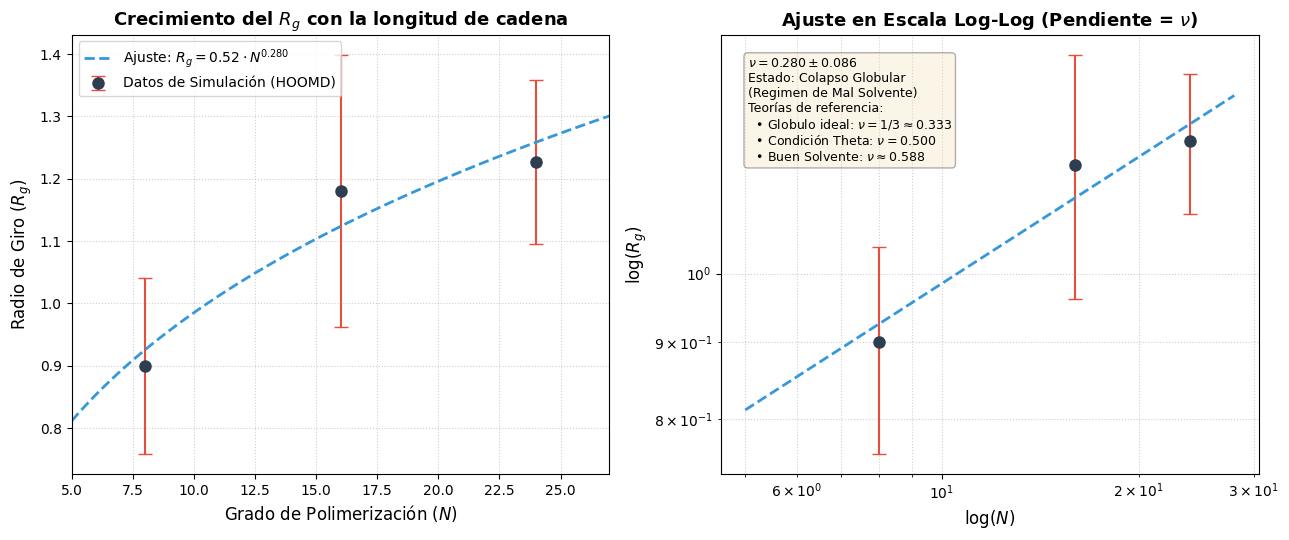

In [21]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Datos obtenidos de tus simulaciones
N = np.array([8, 16, 24])
Rg = np.array([0.8999, 1.1809, 1.2265])
Rg_std = np.array([0.1416, 0.2185, 0.1313]) # Desviaciones estándar para las barras de error

# 2. Definición de la función de ajuste (Ley de potencias: Rg = A * N^nu)
def ley_potencias(N, A, nu):
    return A * (N**nu)

# Realizamos el ajuste no lineal directamente sobre los datos reales
popt, pcov = curve_fit(ley_potencias, N, Rg, p0=[0.3, 0.5])
A_opt, nu_opt = popt
nu_err = np.sqrt(np.diag(pcov))[1] # Error estándar del exponente v

print(f"Resultados del ajuste:")
print(f"  -> Exponente de Flory (v) calculado: {nu_opt:.3f} ± {nu_err:.3f}")
print(f"  -> Constante pre-exponencial (A): {A_opt:.3f}")

# 3. Generación de curvas continuas para el gráfico
N_linea = np.linspace(5, 28, 100)
Rg_ajuste = ley_potencias(N_linea, A_opt, nu_opt)

# --- Configuración del Gráfico con Matplotlib ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), sharey=False)

# FIGURA 1: Escala Lineal (Visualización del crecimiento físico)
ax1.errorbar(N, Rg, yerr=Rg_std, fmt='o', color='#2c3e50', ecolor='#e74c3c', 
             capsize=5, markersize=8, label='Datos de Simulación (HOOMD)')
ax1.plot(N_linea, Rg_ajuste, '--', color='#3498db', linewidth=2,
         label=f'Ajuste: $R_g = {A_opt:.2f} \cdot N^{{{nu_opt:.3f}}}$')

ax1.set_xlabel('Grado de Polimerización ($N$)', fontsize=12)
ax1.set_ylabel('Radio de Giro ($R_g$)', fontsize=12)
ax1.set_title('Crecimiento del $R_g$ con la longitud de cadena', fontsize=13, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.set_xlim(5, 27)
ax1.legend(fontsize=10, loc='upper left')

# FIGURA 2: Escala Log-Log (Linealización para evidenciar el exponente)
ax2.errorbar(N, Rg, yerr=Rg_std, fmt='o', color='#2c3e50', ecolor='#e74c3c', capsize=5, markersize=8)
ax2.plot(N_linea, Rg_ajuste, '--', color='#3498db', linewidth=2)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('$\log(N)$', fontsize=12)
ax2.set_ylabel('$\log(R_g)$', fontsize=12)
ax2.set_title('Ajuste en Escala Log-Log (Pendiente = $\\nu$)', fontsize=13, fontweight='bold')
ax2.grid(True, which="both", linestyle=':', alpha=0.6)

# Añadir una caja de texto con la interpretación física dentro de la gráfica
texto_interpretacion = (
    f"$\\nu = {nu_opt:.3f} \\pm {nu_err:.3f}$\n"
    f"Estado: Colapso Globular\n"
    f"(Regimen de Mal Solvente)\n"
    f"Teorías de referencia:\n"
    f"  • Globulo ideal: $\\nu = 1/3 \\approx 0.333$\n"
    f"  • Condición Theta: $\\nu = 0.500$\n"
    f"  • Buen Solvente: $\\nu \\approx 0.588$"
)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.3)
ax2.text(0.05, 0.95, texto_interpretacion, transform=ax2.transAxes, fontsize=9,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()